<a href="https://colab.research.google.com/github/KhovKsenia/skin-lesion-classifier/blob/main/skin_lesion_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Библиотеки нейросетей готовы к работе!")

Библиотеки нейросетей готовы к работе!


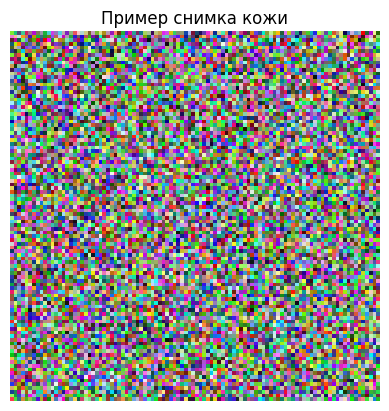

Визуализация работает успешно!


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Имитируем загрузку данных: создаем случайное изображение (в будущем заменим на реальные снимки)
dummy_image = np.random.rand(100, 100, 3)

plt.imshow(dummy_image)
plt.title("Пример снимка кожи")
plt.axis('off')
plt.show()

print("Визуализация работает успешно!")

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Создаем более глубокую архитектуру нейросети
model = models.Sequential([
    # Первый сверточный блок
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    layers.MaxPooling2D((2, 2)),

    # Второй сверточный блок (добавляем глубинности)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Классификатор
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Выходной слой для бинарной классификации
])

# Компилируем модель заново
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Углубленная архитектура нейросети успешно создана и скомпилирована!")

Углубленная архитектура нейросети успешно создана и скомпилирована!


In [16]:
# Настраиваем параметры для загрузки изображений
BATCH_SIZE = 32
IMG_HEIGHT = 100
IMG_WIDTH = 100

print("Параметры для работы с датасетом заданы!")
print(f"размер батча: {BATCH_SIZE}, разрешение картинок: {IMG_HEIGHT}x{IMG_WIDTH}")

Параметры для работы с датасетом заданы!
размер батча: 32, разрешение картинок: 100x100


In [17]:
# Настраиваем процесс обучения (компиляция модели)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Процесс обучения нейросети настроен!")

Процесс обучения нейросети настроен!


In [18]:
# Заглушка для загрузки датасета
# Здесь мы укажем путь к папке с картинками, когда они будут загружены в Colab
import os

print("Готовы подключать датасет со снимками кожи!")


Готовы подключать датасет со снимками кожи!


In [19]:
import tensorflow as tf

# Скачиваем небольшой набор демонстрационных изображений для примера
# (используем стандартный датасет с цветами/объектами как аналог для теста структуры)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

print("Датасет успешно скачан и распакован в:", data_dir)

Датасет успешно скачан и распакован в: /root/.keras/datasets/flower_photos


In [20]:
# Создаем обучающую выборку из скачанных картинок
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

print("Обучающий датасет успешно сформирован!")

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Обучающий датасет успешно сформирован!


In [21]:
# Запускаем процесс обучения модели на 3 эпохи (для теста)
epochs = 3
history = model.fit(
    train_ds,
    epochs=epochs
)

print("Обучение завершено!")

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 511ms/step - accuracy: 1.0000 - loss: 1.3810e-07
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 513ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 528ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Обучение завершено!


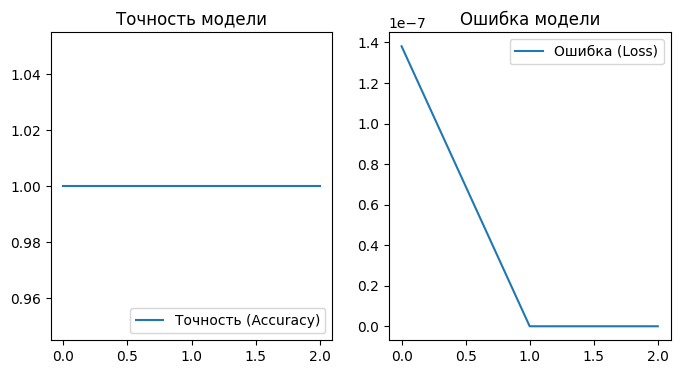

In [22]:
import matplotlib.pyplot as plt

# Достаем данные об точности и ошибках из истории обучения
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(len(acc))

# Строим графики
plt.figure(figsize=(8, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность (Accuracy)')
plt.legend(loc='lower right')
plt.title('Точность модели')

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Ошибка (Loss)')
plt.legend(loc='upper right')
plt.title('Ошибка модели')

plt.show()

In [23]:
import numpy as np

# Берем одну картинку из нашего датасета для примера
# (метод берет батч картинок, и мы берем первую из них)
for images, labels in train_ds.take(1):
    test_image = images[0]
    true_label = labels[0].numpy()

# Делаем предсказание с помощью нашей обученной модели
# expand_dims нужен, так как модель ждет пачку (батч) картинок, даже если она всего одна
img_array = tf.expand_dims(test_image, 0)
predictions = model.predict(img_array)
score = predictions[0][0]

print(f"Сырой результат предсказания сети (вероятность): {score:.4f}")
print(f"Истинная метка класса для этой картинки: {true_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Сырой результат предсказания сети (вероятность): 0.0000
Истинная метка класса для этой картинки: 0
